# Practical 20

**Aim:** Create various types of plots using Matplotlib: line plot, bar chart, histogram, pie chart and scatter plot using subplots and figure properties.

**Dataset:** UCI Mushroom Dataset (ID 73)

**Columns used:** 7 columns — `class`, `cap-shape`, `cap-surface`, `cap-color`, `bruises`, `odor`, `gill-attachment`.

### 1. Load Dataset

The UCI Mushroom dataset is fetched using `ucimlrepo`. Only 7 columns are selected for this practical.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from ucimlrepo import fetch_ucirepo

# Fetch UCI Mushroom dataset (ID 73)
mushroom = fetch_ucirepo(id=73)

X = mushroom.data.features.copy()
y = mushroom.data.targets.copy()

# Combine target and features
df = pd.concat([y, X], axis=1)

# Select only 7 columns for the practical
df = df[['class', 'cap-shape', 'cap-surface', 'cap-color',
         'bruises', 'odor', 'gill-attachment']]

print("Dataset loaded successfully.")
print("Shape:", df.shape)

df.head(5)

Dataset loaded successfully.
Shape: (8124, 7)


class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment
p,x,s,n,t,p,f
e,x,s,y,t,a,f
e,b,s,w,t,l,f
p,x,y,w,t,p,f
e,x,s,g,f,n,f


### 2. Line Plot, Bar Chart, Histogram, Pie Chart and Scatter Plot using Subplots & Figure Properties

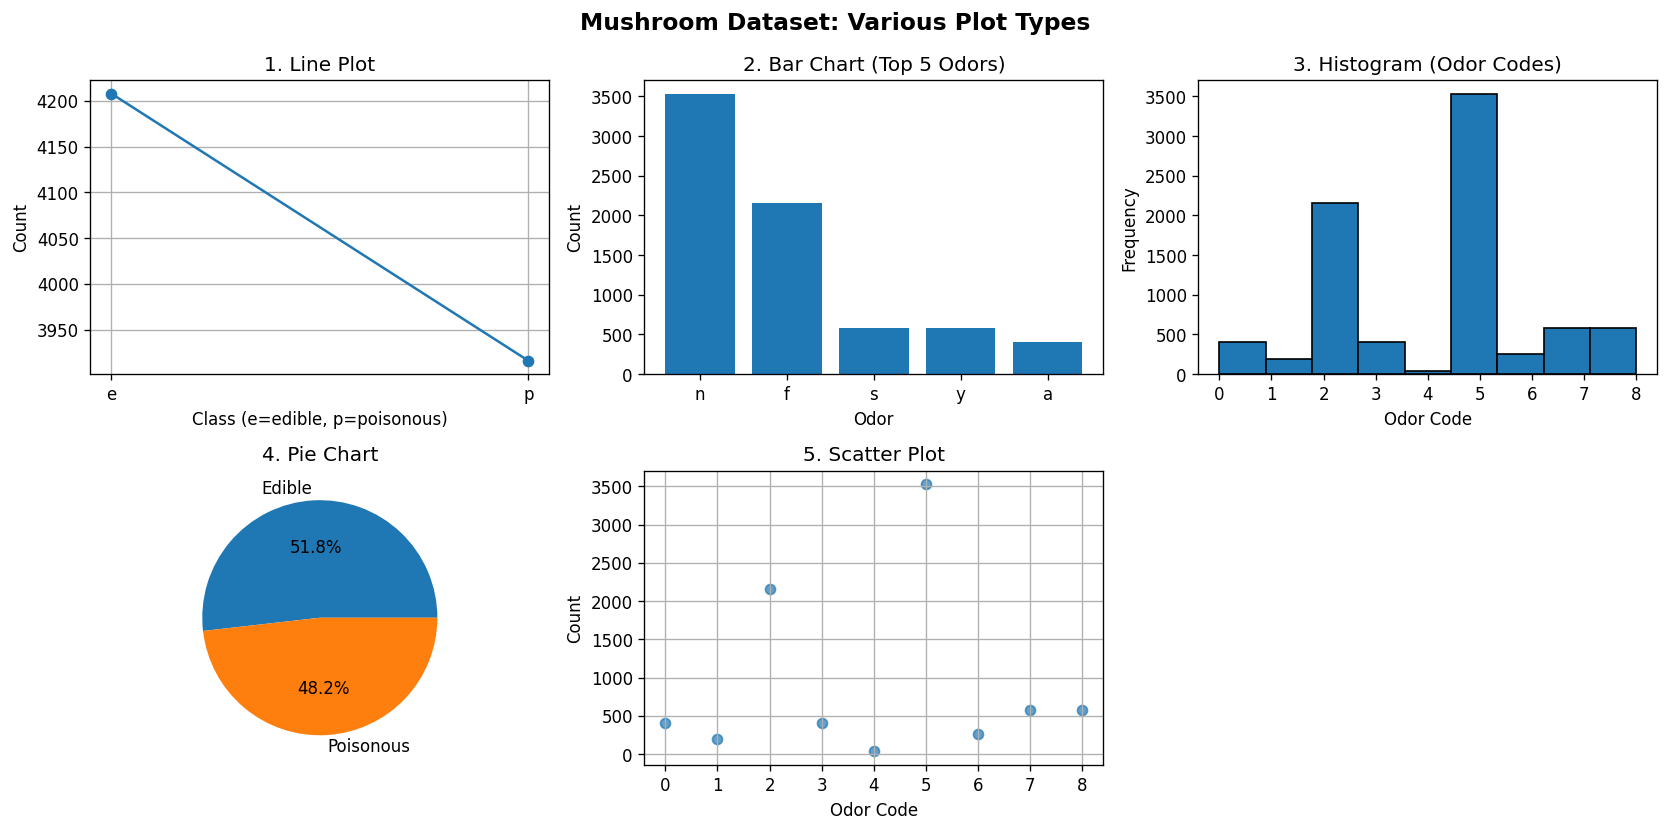

In [ ]:
# Prepare data for the required plots
class_counts = df['class'].value_counts().reindex(['e', 'p'], fill_value=0)

odor_counts = df['odor'].value_counts()
top_odor = odor_counts.head(5)

odor_order = ['a', 'c', 'f', 'l', 'm', 'n', 'p', 's', 'y']
odor_codes = df['odor'].map({v: i for i, v in enumerate(odor_order)})

# Create 2x3 subplots
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
fig.suptitle('Mushroom Dataset: Various Plot Types',
             fontsize=14, fontweight='bold')

# 1. Line Plot
axes[0, 0].plot(class_counts.index, class_counts.values, marker='o')
axes[0, 0].set_title('1. Line Plot')
axes[0, 0].set_xlabel('Class (e=edible, p=poisonous)')
axes[0, 0].set_ylabel('Count')
axes[0, 0].grid(True)

# 2. Bar Chart
axes[0, 1].bar(top_odor.index, top_odor.values)
axes[0, 1].set_title('2. Bar Chart (Top 5 Odors)')
axes[0, 1].set_xlabel('Odor')
axes[0, 1].set_ylabel('Count')

# 3. Histogram
axes[0, 2].hist(odor_codes.dropna(), bins=9, edgecolor='black')
axes[0, 2].set_title('3. Histogram (Odor Codes)')
axes[0, 2].set_xlabel('Odor Code')
axes[0, 2].set_ylabel('Frequency')

# 4. Pie Chart
axes[1, 0].pie(class_counts.values,
                labels=['Edible', 'Poisonous'],
                autopct='%1.1f%%')
axes[1, 0].set_title('4. Pie Chart')

# 5. Scatter Plot
odor_summary = df['odor'].value_counts().reindex(odor_order, fill_value=0)
axes[1, 1].scatter(range(len(odor_order)),
                    odor_summary.values, alpha=0.7)
axes[1, 1].set_title('5. Scatter Plot')
axes[1, 1].set_xlabel('Odor Code')
axes[1, 1].set_ylabel('Count')
axes[1, 1].grid(True)

# Remove unused subplot
fig.delaxes(axes[1, 2])

plt.tight_layout()
plt.show()